# Install Library

In [1]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [2]:
!pip install transformers datasets accelerate evaluate lime
!pip install -U transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3fad81293da9ce9eb66b84bea882295c8a3272905520b862051e7b276c6a6aa3
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 39.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


# Import Library

In [3]:
import transformers
import huggingface_hub
import torch

print("Transformers:", transformers.__version__)
print("HF Hub:", huggingface_hub.__version__)
print("Torch:", torch.__version__)

Transformers: 5.13.1
HF Hub: 1.20.1
Torch: 2.11.0+cu128


In [4]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from datasets import Dataset

from lime.lime_text import LimeTextExplainer

# Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [6]:
# Load Dataset
df = pd.read_csv(
    "/content/drive/MyDrive/Kuliah/Semester 6/Machine Learning/2306116_Rifki Ramdani/experiment/dataset/dataset_1.csv"
)

# Select relevant columns
df = df[['text_new', 'hoax']]

# Rename columns for consistency
df.columns = ['text', 'label']

# Display the first 10 rows
print(df.head(10))

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display label distribution
print("\nLabel Distribution:")
print(df['label'].value_counts())

                                                text  label
0  Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...      1
1  Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...      1
2  Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...      1
3  Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...      1
4  Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...      1
5  Hasil periksa fakta Mochamad Marcell\nFaktanya...      1
6  Hasil periksa fakta Pandan Wangi Sukma Listyon...      1
7  Hasil periksa fakta Pandan Wangi Sukma Listyon...      1
8  Hasil periksa fakta Evarizma Zahra.\nHasil fot...      1
9  Hasil periksa fakta Evarizma Zahra.\nKonten ya...      1

Dataset Shape:
(31310, 2)

Label Distribution:
label
0    20945
1    10365
Name: count, dtype: int64


# Label Normalization

In [7]:
def normalize_label(label):
    label = str(label).lower()

    if label in ['hoax', 'fake', '1']:
        return 1
    else:
        return 0

df['label'] = df['label'].apply(normalize_label)

print(df['label'].value_counts())

label
0    20945
1    10365
Name: count, dtype: int64


# Exploratory Data Analysis (Explore)

## Distribusi Label


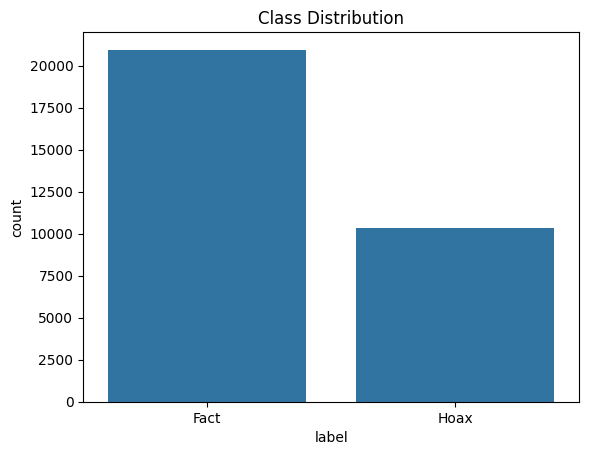

In [8]:
sns.countplot(x=df['label'])
plt.title('Class Distribution')
plt.xticks([0,1], ['Fact', 'Hoax'])
plt.show()

## Word Count

Average Text Length: 276.3014372404982
Minimum Text Length: 1
Maximum Text Length: 4597


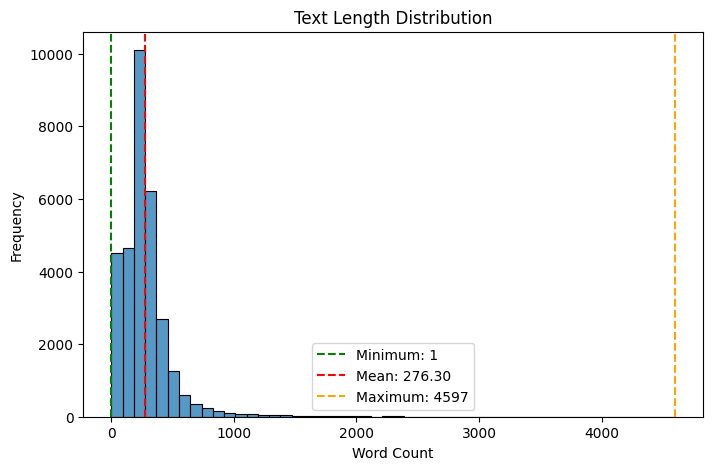

In [9]:
# Calculate text length
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

avg_length = df['word_count'].mean()
min_length = df['word_count'].min()
max_length = df['word_count'].max()

# Display text length statistics
print("Average Text Length:", avg_length)
print("Minimum Text Length:", min_length)
print("Maximum Text Length:", max_length)

# Plot text length distribution
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=50)
plt.title('Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

# Add vertical lines for minimum, mean, and maximum values
plt.axvline(
    min_length,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Minimum: {min_length}'
)

plt.axvline(
    avg_length,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: {avg_length:.2f}'
)

plt.axvline(
    max_length,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'Maximum: {max_length}'
)

# Display legend and plot
plt.legend()
plt.show()

# Missing Value Checking

In [10]:
print("=" * 50)
print("Missing Value Checking")
print("=" * 50)

print(df.isnull().sum())

df.dropna(inplace=True)

print("\nDataset Shape After Removing Missing Values:")
print(df.shape)

Missing Value Checking
text          0
label         0
word_count    0
dtype: int64

Dataset Shape After Removing Missing Values:
(31310, 3)


# Text Preprocessing

In [11]:
# Text Cleaning Function
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
df['clean_text'] = df['text'].astype(str).apply(clean_text)

display(df[['text', 'clean_text']].head())

,text,clean_text
0,Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,hasil periksa fakta gabriela nauli sinaga univ...
1,Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,hasil periksa fakta gabriela nauli sinaga univ...
2,Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,hasil periksa fakta gabriela nauli sinaga univ...
3,Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,hasil periksa fakta gabriela nauli sinaga univ...
4,Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,hasil periksa fakta gabriela nauli sinaga univ...


# Duplicate Removal

In [12]:
print("="*50)
print("Duplicate Removal Based on Preprocessed Text")
print("="*50)

duplicate_before = df.duplicated(subset=["clean_text"]).sum()

print(f"Duplicate documents before removal : {duplicate_before}")

df = (df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True))

duplicate_after = df.duplicated(subset=["clean_text"]).sum()

print(f"Duplicate documents after removal  : {duplicate_after}")
print(f"\nFinal Dataset Shape : {df.shape}")

Duplicate Removal Based on Preprocessed Text
Duplicate documents before removal : 8
Duplicate documents after removal  : 0

Final Dataset Shape : (31302, 4)


# Dataset Statistics

In [13]:
print("="*50)
print("Final Dataset Statistics")
print("="*50)

print(df["label"].value_counts())

print()

print(df["label"].value_counts(normalize=True))

Final Dataset Statistics
label
0    20945
1    10357
Name: count, dtype: int64

label
0    0.669127
1    0.330873
Name: proportion, dtype: float64


# Dataset Splitting

In [14]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("="*50)
print("Dataset Splitting")
print("="*50)

print(f"Training   : {len(train_texts)}")
print(f"Validation : {len(val_texts)}")
print(f"Testing    : {len(test_texts)}")

Dataset Splitting
Training   : 25041
Validation : 3130
Testing    : 3131


In [15]:
print("="*50)
print("Label Distribution")
print("="*50)

print("\nTraining")
print(train_labels.value_counts())

print("\nValidation")
print(val_labels.value_counts())

print("\nTesting")
print(test_labels.value_counts())

Label Distribution

Training
label
0    16756
1     8285
Name: count, dtype: int64

Validation
label
0    2094
1    1036
Name: count, dtype: int64

Testing
label
0    2095
1    1036
Name: count, dtype: int64


# Data Leakage Checking

In [16]:
train_set = set(train_texts)
val_set = set(val_texts)
test_set = set(test_texts)

print("="*50)
print("Overlap Checking")
print("="*50)

print("Train-Test:", len(train_set & test_set))
print("Train-Val:", len(train_set & val_set))
print("Val-Test:", len(val_set & test_set))

Overlap Checking
Train-Test: 0
Train-Val: 0
Val-Test: 0


# Load IndoBERT Tokenizer

In [17]:
model_name = "indobenchmark/indobert-base-p2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# Text Tokenization

In [18]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

# Convert to HuggingFace Dataset

In [19]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': list(val_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': list(test_labels)
})

# Compute Class Weight

In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([0.7472, 1.5112])


# Load IndoBERT Model

In [21]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Define Custom Trainer

In [22]:
from torch.nn import CrossEntropyLoss

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Evaluation Metrics

In [23]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

# Training Arguments

In [24]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=50,
    greater_is_better=True,
    seed=42,
    save_total_limit=1,
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Initialize Trainer

In [25]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

# Hardware Information

In [26]:
import time
import transformers
import psutil

print("="*50)
print("Hardware Information")
print("="*50)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"GPU Memory: {props.total_memory / (1024**3):.2f} GB")
else:
    print("Running on CPU")

print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
print(f"CPU Cores : {psutil.cpu_count(logical=True)}")
print(f"RAM : {psutil.virtual_memory().total/(1024**3):.2f} GB")

Hardware Information
GPU: Tesla T4
GPU Memory: 14.56 GB
PyTorch Version: 2.11.0+cu128
Transformers Version: 5.13.1
CPU Cores : 2
RAM : 12.67 GB


# Fine-Tuning Model

In [27]:
print("="*50)
print("Start Training")
print("="*50)

start_time = time.time()

trainer.train()

end_time = time.time()

training_time = end_time - start_time

print("="*50)
print("Training Time")
print("="*50)

print(f"{training_time:.2f} seconds")
print(f"{training_time/60:.2f} minutes")

Start Training


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.021738,0.031349,0.994569,0.999021,0.984556,0.991736
2,0.000071,0.028855,0.996486,0.995169,0.994208,0.994689
3,0.000007,0.024267,0.997764,0.998064,0.995174,0.996617
4,0.000003,0.032977,0.997764,0.999030,0.994208,0.996613
5,0.000002,0.027674,0.997764,0.999030,0.994208,0.996613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Time
3216.89 seconds
53.61 minutes


# Model Evaluation on Test Set

In [28]:
import time

print("="*50)
print("Model Evaluation on Test Set")
print("="*50)

start_inference = time.time()

predictions = trainer.predict(test_dataset)

end_inference = time.time()

inference_time = end_inference - start_inference

y_pred = np.argmax(predictions.predictions, axis=1)
y_prob = predictions.predictions

y_true = test_labels.to_numpy()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1-Score  : {f1:.6f}")

print(f"\nInference Time : {inference_time:.2f} seconds")

Model Evaluation on Test Set


Accuracy  : 0.997764
Precision : 0.998064
Recall    : 0.995174
F1-Score  : 0.996617

Inference Time : 26.88 seconds


In [29]:
results_df = pd.DataFrame({
    "text": list(test_texts),
    "true_label": y_true,
    "predicted_label": y_pred
})

results_df.head()

,text,true_label,predicted_label
0,bukan diganti lagu indonesia raya di video itu...,1,1
1,suara penolakan penundaan pemilu dan presiden ...,0,0
2,hasil periksa fakta renanda dwina putri anggot...,1,1
3,gila kalau ada yang percaya berita tak benar i...,1,1
4,kpu tetapkan 17 partai peserta pemilu 2024 und...,0,0


# Classification Report

In [30]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['Fact', 'Hoax']
))

              precision    recall  f1-score   support

        Fact       1.00      1.00      1.00      2095
        Hoax       1.00      1.00      1.00      1036

    accuracy                           1.00      3131
   macro avg       1.00      1.00      1.00      3131
weighted avg       1.00      1.00      1.00      3131



# Confusion Matrix

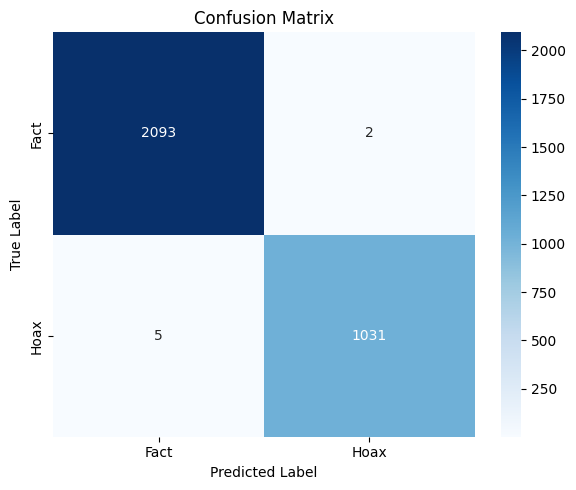

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fact","Hoax"],
    yticklabels=["Fact","Hoax"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

# Bootstrap Confidence Interval

In [32]:
from sklearn.utils import resample

print("="*50)
print("Bootstrap Confidence Interval")
print("="*50)

n_bootstrap = 1000
bootstrap_scores = []

for i in range(n_bootstrap):
    indices = resample(
        np.arange(len(y_true)),
        replace=True,
        n_samples=len(y_true),
        random_state=i
    )

    score = accuracy_score(
        y_true[indices],
        y_pred[indices]
    )

    bootstrap_scores.append(score)

lower = np.percentile(bootstrap_scores, 2.5)
upper = np.percentile(bootstrap_scores, 97.5)

print(f"Accuracy               : {accuracy:.6f}")
print(f"95% Confidence Interval: [{lower:.6f}, {upper:.6f}]")

Bootstrap Confidence Interval
Accuracy               : 0.997764
95% Confidence Interval: [0.996167, 0.999361]


# Bootstrap Accuracy Distribution

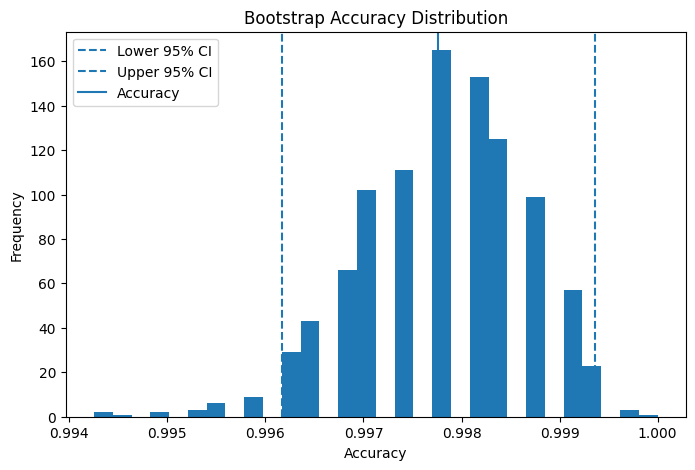

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    bootstrap_scores,
    bins=30
)

plt.axvline(lower, linestyle="--", label="Lower 95% CI")
plt.axvline(upper, linestyle="--", label="Upper 95% CI")
plt.axvline(accuracy, linestyle="-", label="Accuracy")

plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Bootstrap Accuracy Distribution")

plt.legend()

plt.show()

# Initialize LIME Explainer

In [34]:
class_names = ['Fact', 'Hoax']

explainer = LimeTextExplainer(class_names=class_names)

# Define Prediction Function for LIME

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

def predictor(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # switch to GPU / device model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

# Single Text Prediction

In [36]:
def predict_single_text(text, expected_label=""):
    # Text Cleaning
    if 'clean_text' in dir():
        text = clean_text(text)

    words = text.split()
    wrapped_text = "\n".join(
        [" ".join(words[i:i+20]) for i in range(0, len(words), 20)]
    )

    # Tokenization
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()
    label_pred = "Hoax" if prediction == 1 else "Fact"

    print("\n===================================")
    print("NARRATIVE:")
    print(wrapped_text)
    print("\n===================================")
    print(f"MODEL PREDICTION: {label_pred}")

    return text, label_pred, prediction

# Run LIME Explanation

In [44]:
import gc

def run_lime(text_instance, actual_label):
    model.to(device)
    model.eval()

    # Model Prediction
    text_cleaned, label_pred, prediction = predict_single_text(text_instance)

    # Clean GPU Cache
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # LIME Explanation
    print("\nCalculating LIME explanation...")

    exp = explainer.explain_instance(
        text_cleaned,
        predictor,
        num_features=10,
        num_samples=100
    )

    # Most Influential Words
    print("\nMost Influential Words:")

    for word, score in exp.as_list():
        print(f"{word:20} : {score:.4f}")

    # Visualization
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(10,5)

    plt.title("LIME Explanation")
    plt.grid(True, alpha=0.3)
    plt.show()

    #Saave Keywords
    for word, score in exp.as_list():
        lime_results.append({
            "Actual Label": actual_label,
            "Predicted Label": label_pred,
            "Keyword": word,
            "Weight": score
        })

    print("\n")
    return exp

# Select Sample News for LIME Analysis

In [48]:
print("="*50)
print("Sample News for LIME Analysis")
print("="*50)

# Take 5 factual news and 5 fake news at random
fact_samples = (
    df[df["label"] == 0]
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

hoax_samples = (
    df[df["label"] == 1]
    .sample(n=5, random_state=42)
    .reset_index(drop=True)
)

lime_samples = pd.concat(
    [fact_samples, hoax_samples],
    ignore_index=True
)

display(
    lime_samples[
        ["clean_text", "label"]
    ]
)

Sample News for LIME Analysis


,clean_text,label
0,kpu sebut anggaran pemilu 2024 mengacu sistem ...,0
1,biografi tokoh dunia benjamin netanyahu prajur...,0
2,kib soal nama capres ganjar erick dan sandiaga...,0
3,peneliti duga kepentingan pelarian jika dpr je...,0
4,sby mungkin hukum bisa dibeli tapi tidak untuk...,0
5,faktanya memang ada metode serupa tapi tak sam...,1
6,disinformasi yang pernah beberapa kali diedark...,1
7,klinik misinformasi webinar rabu 26 agustus 20...,1
8,hasil periksa fakta gabriela nauli sinaga univ...,1
9,hasil periksa fakta renanda dwina putri anggot...,1


# Initialize LIME Results Storage

In [46]:
lime_results = []

# Generate LIME Explanations

Sample 1
Actual Label: Fact

NARRATIVE:
KPU Sebut Anggaran Pemilu 2024 Mengacu Sistem Proporsional Terbuka Komisi Pemilihan Umum (KPU) memastikan anggaran untuk Pemilu 2024 masih menggunakan
skema pemilu dengan sistem proporsional terbuka. Anggaran tersebut sudah meliputi biaya untuk desain surat suara, alat perlengkapan pemungutan suara, dan
sebagainya.Ketua KPU Hasyim Asy'ari menyebut anggaran pemilu tersebut telah disetujui dalam daftar isian pelaksanaan anggaran (DIPA) oleh Presiden Joko Widodo.
Hal itu ia sampaikan dalam rapat kerja bersama Komisi II di Kompleks Parlemen, Rabu (11/1). "Dan perlu juga kami sampaikan
bahwa anggaran untuk tahun 2023, dan selanjutnya 2024 dirancang dan disusun tetap dengan menggunakan cara pandang sebagaimana yang berlaku dalam
Undang-Undang Pemilu yaitu sistem proporsional daftar calon terbuka," kata Hasyim.Hasyim selanjutnya membeberkan anggaran pemilu pada 2022, yakni sebesar Rp8,061 triliun
dan yang disetujui dalam DIPA sebesar Rp3,63 triliun. Sel

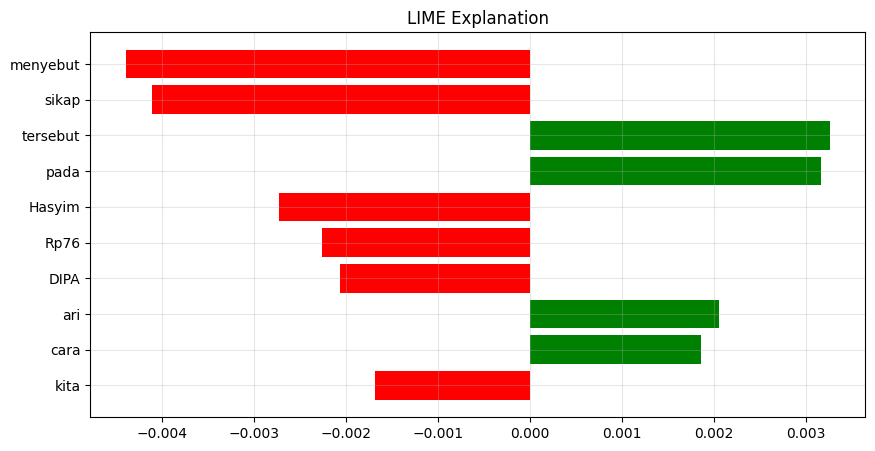



Sample 2
Actual Label: Fact

NARRATIVE:
Biografi Tokoh Dunia: Benjamin Netanyahu, Prajurit Veteran Israel Pemegang Komando Serangan ke Gaza Di tengah kecaman internasional atas serangan Israel
ke Gaza, Perdana Menteri Israel Benjamin Netanyahu tak goyah pada kebijakannya. Dalam pidatonya di televisi dia mengklaim, "Kampanye kami melawan
organisasi teroris terus berlanjut dengan kekuatan penuh. Kami bertindak sekarang, selama diperlukan, untuk memulihkan ketenangan dan ketentraman Anda, warga Israel.
Ini akan memakan waktu." Sementara itu, dia mengatakan hilangnya 188 nyawa, termasuk 55 anak, dalam serangan Israel ke Gaza seminggu
terakhir sebagai suatu ketidaksengajaan. Kampanye anti-terorisme, bukan pertama kali digaungkan pria, yang oleh pendukungnya disebut sebagai “Raja Bibi” ini. Perjuangan
melawan terorisme sudah dia mulai sejak menjadi prajurit muda. Isu keamanan ini juga menjadi pendorongnya untuk aktif di ranah politik
Israel. Bahkan jajak pendapat di Israel menilai keberhas

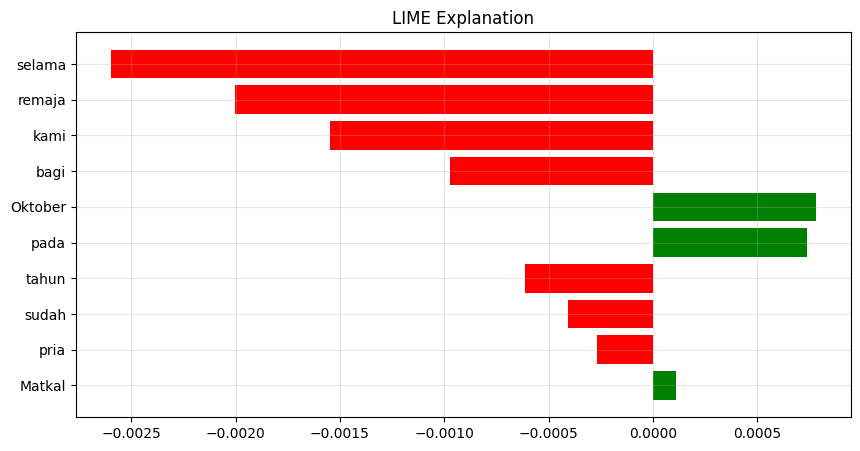



Sample 3
Actual Label: Fact

NARRATIVE:
KIB Soal Nama Capres: Ganjar, Erick dan Sandiaga Intens Komunikasi Wasekjen PPP Idy Muzayyad mengungkapkan nama Gubernur Jawa Tengah Ganjar
Pranowo, Menteri BUMN Erick Thohir dan Menteri Pariwisata dan Ekonomi Kreatif Sandiaga Uno selama ini intens berkomunikasi dengan Koalisi Indonesia
Bersatu (KIB) yang digagas partainya bersama Golkar dan PAN.Hal demikian Ia sampaikan ketika ditanyakan soal nama-nama capres yang bakal diusung
KIB pada Pilpres 2024 mendatang."Kalau bicara nama-nama memang ada yang selama ini intens. Ya nama-nama yang sudah ada itu. Ada
Ganjar dan yang lainnya. Kan ada Erick, ada Sandi dan sebagainya. Ya beberapa nama itu," kata Idy dalam diskusi politik
yang digelar di Kopi Politik, Jakarta Selatan, Sabtu (7/1). Pilihan RedaksiSandiaga Uno Disebut Bakal Hadiri Silaturahmi Akbar PPP di YogyaICW
Soal Romahurmuziy Aktif di PPP Lagi: Parpol Rasanya Kurang OrangPrabowo Buka Suara Soal Waktu Penentuan Sosok Cawapres 2024Idy mengkla

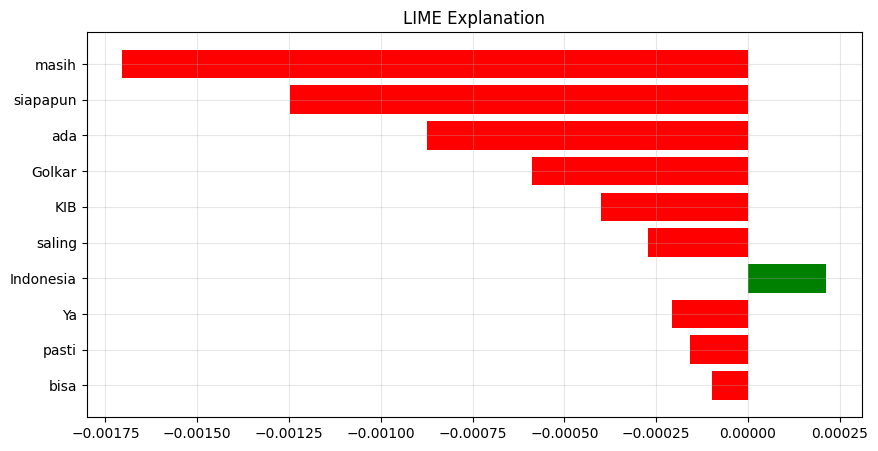



Sample 4
Actual Label: Fact

NARRATIVE:
Peneliti Duga Kepentingan Pelarian jika DPR Jegal Ekstradisi Singapura Peneliti Forum Masyarakat Peduli Parlemen Indonesia (Formappi) Lucius Karus menduga ada
kepentingan lain yang patut dicurigai jika DPR menjegal ratifikasi perjanjian ekstradisi antara Indonesia dengan Singapura.Perjanjian ekstradisi itu telah disepakati dua
negara dalam pertemuan Presiden RI Joko Widodo (Jokowi) dan Perdana Menteri Singapura Lee Hsien Loong di Bintan, Kepulauan Riau, Selasa
(25/1).Lucius mengatakan selama ini usulan pemerintah mulus dibahas di DPR. Namun, ia menduga akan ada perlakuan berbeda terhadap ratifikasi perjanjian
ekstradisi ini. "Jika nanti ternyata nasib ratifikasi ini berbeda dari sikap DPR atas RUU-RUU usulan Pemerintah, maka ada kepentingan berbeda
antara Presiden dan DPR terkait ekstradisi ini," ucap Lucius kepada CNNIndonesia.com, Kamis (27/1)."Kepentingan berbeda ini tampaknya masih soal peluang Singapura
menjadi tempat pelarian yang aman ji

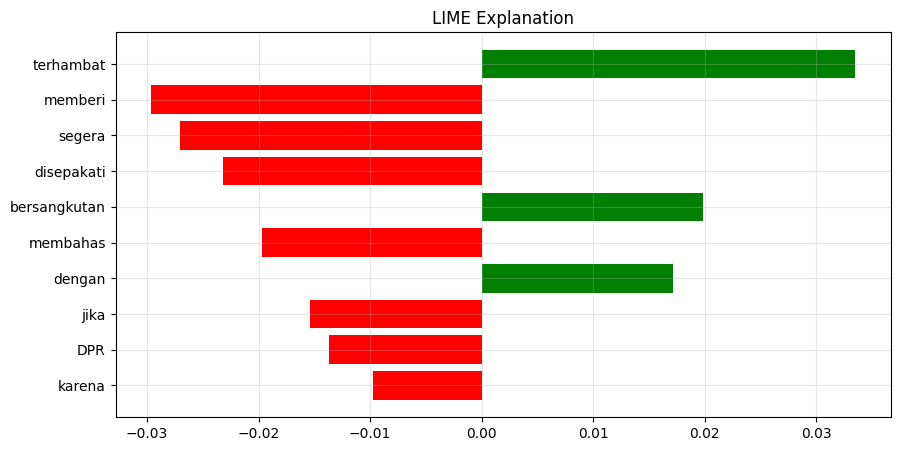



Sample 5
Actual Label: Fact

NARRATIVE:
SBY: Mungkin Hukum Bisa Dibeli, Tapi Tidak untuk Keadilan Presiden RI keenam yang juga Ketua Majelis Tinggi Partai Demokrat, Susilo
Bambang Yudhoyono (SBY) mengatakan hukum mungkin bisa dibeli, tapi keadilan tidak.SBY bicara tersebut di tengah babak baru kisruh Demokrat. Terbaru,
Yusril Ihza Mahendra menjadi kuasa hukum kader kubu Moeldoko yang menggugat AD/ART Demokrat ke Mahkamah Agung."Money can buy many things,
but not everything. Mungkin hukum bisa dibeli, tapi tidak untuk keadilan," kata SBY dalam cuitannya, Senin (27/9). Dia berharap para
penegak hukum berjuang agar hukum tidak berjarak dengan keadilan."Sungguhpun saya masih percaya pada integritas para penegak hukum, berjuanglah agar hukum
tidak berjarak dengan keadilan," kata SBY.SBY tidak menyinggung secara gamblang kasus kepengurusan Demokrat yang ingin diambil alih. Akan tetapi, SBY
menyatakan itu di tengah kisruh memasuki babak baru, yakni keterlibatan Yusril Ihza Mahendra yang mer

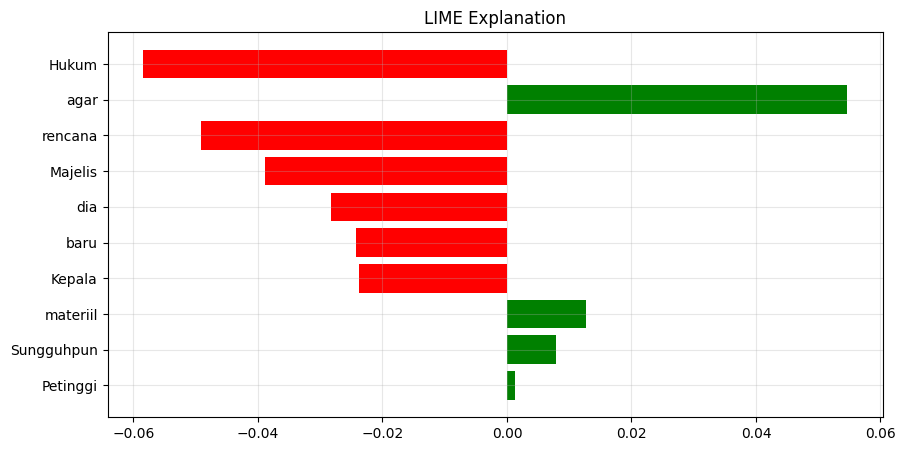



Sample 6
Actual Label: Hoax

NARRATIVE:
Faktanya, memang ada metode serupa tapi tak sama, bukan berarti “disetubuhi”. Metode tersebut adalah “Skin to Skin Care” (SSC) atau
yang dikenal juga dengan nama “Kanggaroo Care”. Tapi metode tersebut hanya dapat dilakukan apabila sudah tidak ada lagi cara lain
untuk menghangatkan korban yang terkena serangan hipotermia atau bahkan sudah dalam kondisi darurat. Karena masih ada banyak cara untuk mengatasi
serangan hipotermia. Selengkapnya di bagian PENJELASAN dan REFERENSI =============================================Kategori : KLARIFIKASI ============================================= Belakangan ini sempat beredar klaim dimana ada cara
untuk mencegah serangan hipotermia saat mendaki gunung, yaitu dengan cara “disetubuhi”. Klaim ini diduga berasal dari akun Youtube yang mengklaim
bahwa dirinya berhasil mencegah temannya terkena serangan hipotermia dengan cara “disetubuhi”. Berikut narasinya:“Yg paling darurat jika sdh sampai tahap hipo
mesti dise

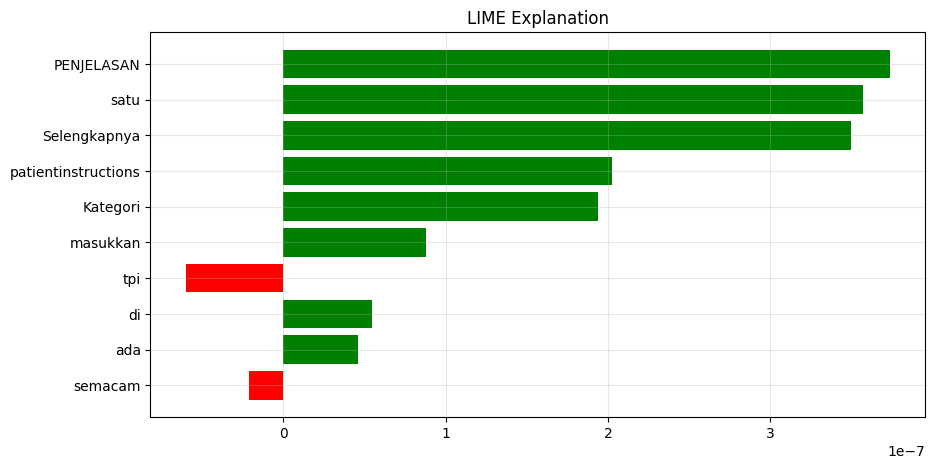



Sample 7
Actual Label: Hoax

NARRATIVE:
Disinformasi yang pernah beberapa kali diedarkan sebelumnya, pil tersebut bukan berasal dari China tetapi dari Turki. Selengkapnya di bagian PENJELASAN.
====== KATEGORI Disinformasi. ====== SUMBER (1) Pertanyaan dari salah satu anggota FAFHH. (2) http://bit.ly/2Pkm5Yk, post oleh akun “Abim Bima” (facebook.com/abim.bima.7503),
sudah dibagikan 3.637 kali per tangkapan layar dibuat. ====== PENJELASAN (1) http://bit.ly/2rhTadC / http://bit.ly/2MxVN7S, firsdraftnews.org: “Konten yang Salah Ketika konten
yang asli dipadankan dengan konteks informasi yang salah”. —— (2) Selengkapnya di post sebelumnya di http://bit.ly/2onIiZX ====== Sumber: https://www.facebook.com/groups/fafhh/permalink/738873703111834/

MODEL PREDICTION: Hoax

Calculating LIME explanation...

Most Influential Words:
SUMBER               : 0.0000
post                 : 0.0000
dengan               : 0.0000
Konten               : 0.0000
ly                   : 0.0000
Abim               

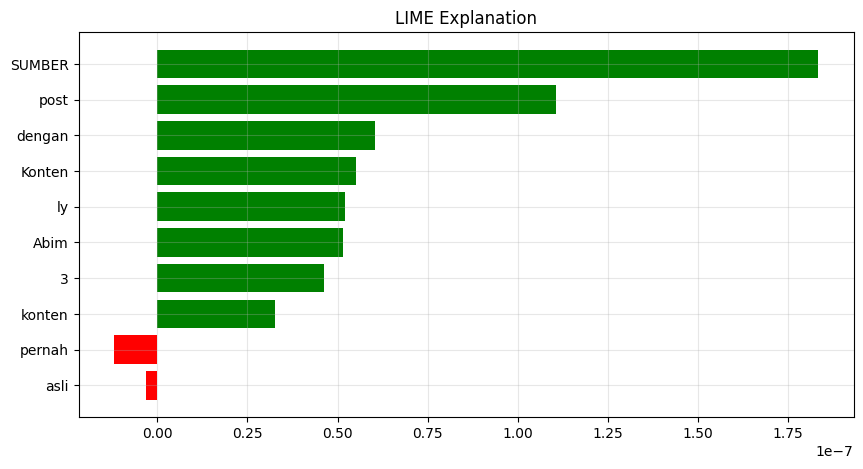



Sample 8
Actual Label: Hoax

NARRATIVE:
Klinik Misinformasi: Webinar | Rabu, 26 Agustus 2020 19:00–21:00 WIB. Simak di: #LawanHoax #FactCheck #DigitalLiteracy

MODEL PREDICTION: Hoax

Calculating LIME explanation...

Most Influential Words:
FactCheck            : 0.0638
26                   : 0.0522
DigitalLiteracy      : 0.0456
Klinik               : 0.0409
Agustus              : -0.0401
00                   : -0.0397
Simak                : 0.0373
Webinar              : 0.0329
Rabu                 : -0.0296
LawanHoax            : 0.0251


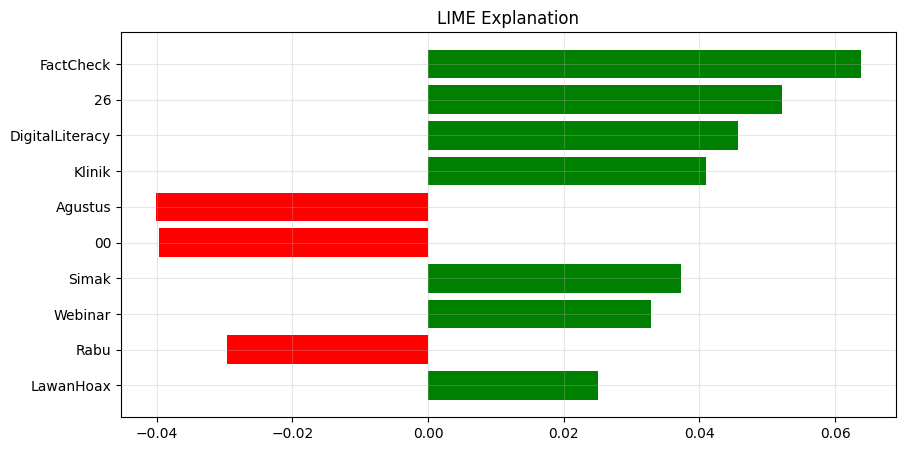



Sample 9
Actual Label: Hoax

NARRATIVE:
Hasil Periksa Fakta Gabriela Nauli Sinaga (Universitas Sumatera Utara) Faktanya, pihak kepolisian tidak akan menilang pengendara motor yang memakai sendal
saat berkendara. Hal ini hanya himbauan kepada masyarakat agar tidak terjadi hal-hal yang tidak diinginkan seperti luka, dll. Selengkapnya hanya
ada di penjelasan. =====[KATEGORI]: MISLEADING CONTENT/Konten Menyesatkan ===== [SUMBER]: WHATSAPP archive.fo/uGSs1 ===== [NARASI]: “Pakai Sendal Jepit Saat Naik Motor Bakal
Ditilang” =====[PENJELASAN]: Beredar sebuah gambar surat kabar yang berjudul “Pakai Sendal Jepit Saat Naik Motor Bakal Ditilang”. Tampilan surat kabar
ini menampilkan 3 aparat kepolisian yang terlihat sedang memberikan pengarahan. Namun setelah ditelusuri, kabar yang menyatakan bahwa pengendara motor yang
tidak memakai sendal akan ditilang, merupakan informasi yang salah. Melansir dari artikel Kompas.com, Kepala Subdirektorat Penegakan Hukum (Kasubdit Gakkum) Ditlantas
Polda Metr

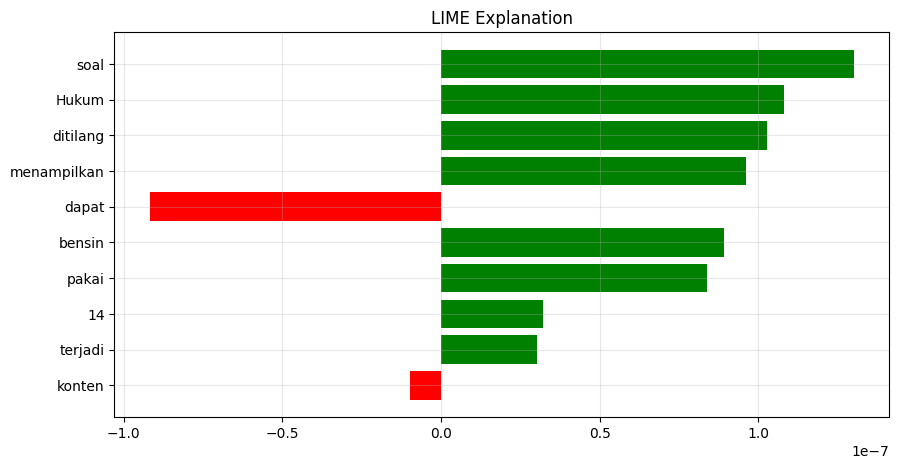



Sample 10
Actual Label: Hoax

NARRATIVE:
Hasil Periksa Fakta Renanda Dwina Putri (Anggota Komisariat MAFINDO Universitas Pendidikan Indonesia). Video tahun 2007. Bukan berdoa untuk musibah virus
Corona saat ini, melainkan untuk persatuan umat muslim dunia, 30 Mei 2007 di Masjid Badshahi, Pakistan. Selengkapnya di bagian pembahasan.
==== Kategori: Konten yang Menyesatkan, Konten yang Salah ==== Narasi: “Doa Assyeikh sudais imam besar masjidil haram mekah terhadap musibah
virus corona yang melanda umat saat ini mari kita Aamiin kan Doa bersama… 🤲🤲🤲🙏🙏🙏sebarkan” ==== Sumber: Facebook http://archive.vn/6LzwC ==== Penjelasan:
Akun Facebook Izul Maz mengunggah sebuah video berdurasi 5.53 menit di laman pribadinya dengan narasi “Doa Assyeikh sudais imam besar
masjidil haram mekah terhadap musibah virus corona yang melanda umat saat ini mari kita Aamiin kan Doa bersama… 🤲🤲🤲🙏🙏🙏 sebarkan”
pada 9 Maret 2020. Unggahan tersebut telah mendapatkan respon sebanyak 17 ribu reaksi, 7,1 ribu komentar, d

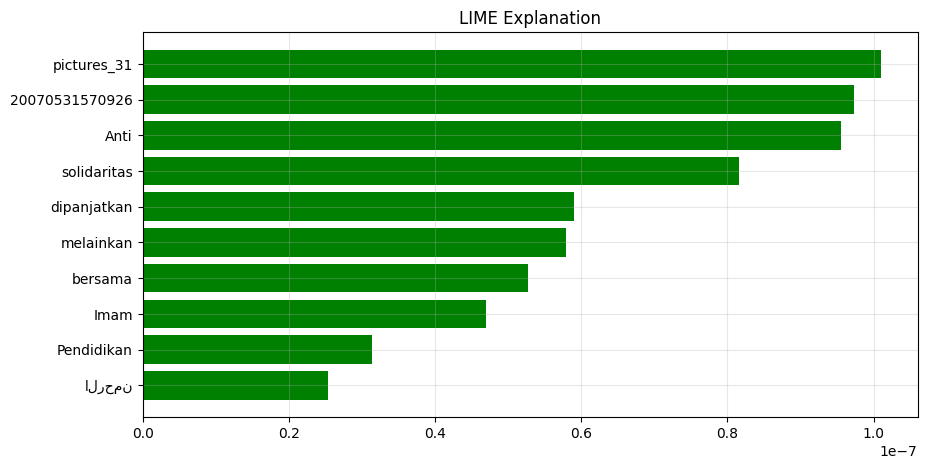

In [47]:
for i in range(len(lime_samples)):
    print("=" * 80)
    print(f"Sample {i + 1}")
    print("=" * 80)

    actual_label = (
        "Hoax"
        if lime_samples.loc[i, "label"] == 1
        else "Fact"
    )

    print("Actual Label:", actual_label)

    run_lime(
        lime_samples.loc[i, "text"],
        actual_label
    )

# Create LIME Results Table

In [49]:
lime_results_df = pd.DataFrame(lime_results)

lime_results_df.head(20)

,Actual Label,Predicted Label,Keyword,Weight
0,Fact,Fact,menyebut,-0.004398
1,Fact,Fact,sikap,-0.004110
2,Fact,Fact,tersebut,0.003265
3,Fact,Fact,pada,0.003168
4,Fact,Fact,Hasyim,-0.002729
5,Fact,Fact,Rp76,-0.002263
6,Fact,Fact,DIPA,-0.002069
7,Fact,Fact,ari,0.002059
8,Fact,Fact,cara,0.001865
9,Fact,Fact,kita,-0.001685


In [50]:
print(lime_samples["label"].value_counts())

label
0    5
1    5
Name: count, dtype: int64


In [51]:
lime_results_df["Actual Label"].value_counts()

,count
Actual Label,
Fact,50
Hoax,50


In [52]:
lime_results_df.tail(20)

,Actual Label,Predicted Label,Keyword,Weight
80,Hoax,Hoax,soal,1.301947e-07
81,Hoax,Hoax,Hukum,1.080768e-07
82,Hoax,Hoax,ditilang,1.028040e-07
83,Hoax,Hoax,menampilkan,9.621201e-08
84,Hoax,Hoax,dapat,-9.180834e-08
85,Hoax,Hoax,bensin,8.921179e-08
86,Hoax,Hoax,pakai,8.387863e-08
87,Hoax,Hoax,14,3.205714e-08
88,Hoax,Hoax,terjadi,3.023916e-08
89,Hoax,Hoax,konten,-9.705627e-09


# Export LIME Results

In [53]:
lime_results_df.to_csv(
    "/content/drive/MyDrive/Kuliah/Semester 6/Machine Learning/2306116_Rifki Ramdani/experiment/dataset/lime_keyword.csv",
    index=False
)